In [1]:
#2
import pandas as pd

df = pd.read_csv("/content/finaldataset.csv")
df.head()


,text,label
0,tum jaise logon se baat nahi karte Aur sach me...,1
1,thanks for your support yaar,0
2,teri aukaat kya hai samjhta hai Sab ke saamne ...,1
3,bakwas band kar Teri baaton se sirf ye lagta h...,1
4,idiot kahi ka Group me bas tu hi hai jo hamesh...,1


In [2]:
#3
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)


In [8]:
#4
train_enc = tokenizer(
    list(train_texts),
    truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="tf"
)

val_enc = tokenizer(
    list(val_texts),
    truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="tf"
)


In [9]:
#6
import tensorflow as tf

input_ids = tf.keras.layers.Input(shape=(128,), dtype=tf.int32)
attention_mask = tf.keras.layers.Input(shape=(128,), dtype=tf.int32)

# Muril output
muril_outputs = muril_base({
    "input_ids": input_ids,
    "attention_mask": attention_mask
})
pooled_output = muril_outputs.pooler_output

# Optimization layers
x = tf.keras.layers.Dropout(0.3)(pooled_output)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(
    inputs=[input_ids, attention_mask],
    outputs=output
)


In [10]:
#7
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 128)]                0         []                            
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   2375562   ['input_1[0][0]',             
 )                           ngAndCrossAttentions(last_   24         'input_2[0][0]']             
                             hidden_state=(None, 128, 7                                           
                             68),                                                             

In [11]:
#8
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


In [12]:
#9
history = model.fit(
    [train_enc["input_ids"], train_enc["attention_mask"]],
    train_labels,
    validation_data=(
        [val_enc["input_ids"], val_enc["attention_mask"]],
        val_labels
    ),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler]
)


Epoch 1/30
117/117 [==============================] - 57s 376ms/step - loss: 0.6876 - accuracy: 0.6157 - val_loss: 0.6820 - val_accuracy: 0.6335 - lr: 2.0000e-05
Epoch 2/30
117/117 [==============================] - 41s 353ms/step - loss: 0.6781 - accuracy: 0.6333 - val_loss: 0.6735 - val_accuracy: 0.6335 - lr: 2.0000e-05
Epoch 3/30
117/117 [==============================] - 41s 351ms/step - loss: 0.6707 - accuracy: 0.6333 - val_loss: 0.6674 - val_accuracy: 0.6335 - lr: 2.0000e-05
Epoch 4/30
117/117 [==============================] - 41s 351ms/step - loss: 0.6654 - accuracy: 0.6333 - val_loss: 0.6634 - val_accuracy: 0.6335 - lr: 2.0000e-05
Epoch 5/30
117/117 [==============================] - 41s 351ms/step - loss: 0.6624 - accuracy: 0.6333 - val_loss: 0.6606 - val_accuracy: 0.6335 - lr: 2.0000e-05
Epoch 6/30
117/117 [==============================] - 41s 352ms/step - loss: 0.6603 - accuracy: 0.6333 - val_loss: 0.6591 - val_accuracy: 0.6335 - lr: 2.0000e-05
Epoch 7/30
117/117 [========

In [4]:
#1
from transformers import AutoTokenizer, TFAutoModel

tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")
muril_base = TFAutoModel.from_pretrained("google/muril-base-cased")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be ab

In [7]:
#5
for layer in muril_base.layers:
    layer.trainable = False


In [13]:
#10
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]

print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")


Final Training Accuracy: 63.33%
Final Validation Accuracy: 63.35%


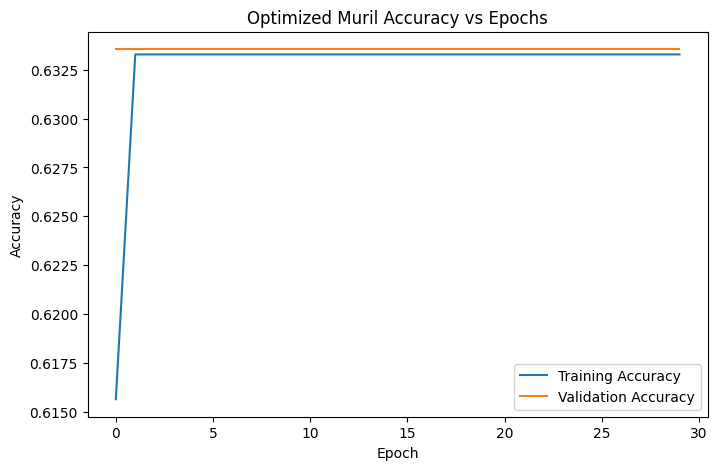

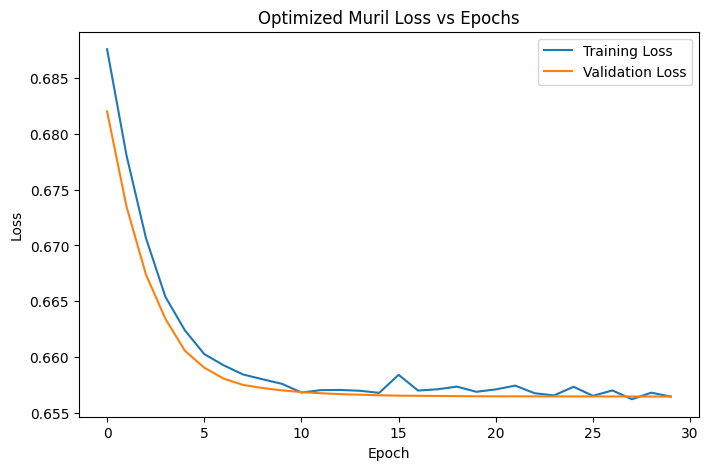

In [14]:
#11
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Optimized Muril Accuracy vs Epochs")
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimized Muril Loss vs Epochs")
plt.legend()
plt.show()


In [15]:
#12
# Unfreeze last 4 transformer layers
for layer in muril_base.layers[-4:]:
    layer.trainable = True


In [16]:
#13
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [17]:
#14
history_ft = model.fit(
    [train_enc["input_ids"], train_enc["attention_mask"]],
    train_labels,
    validation_data=(
        [val_enc["input_ids"], val_enc["attention_mask"]],
        val_labels
    ),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler]
)


Epoch 1/20
117/117 [==============================] - 146s 876ms/step - loss: 0.5399 - accuracy: 0.6830 - val_loss: 0.3511 - val_accuracy: 0.9786 - lr: 1.0000e-05
Epoch 2/20
117/117 [==============================] - 98s 840ms/step - loss: 0.2847 - accuracy: 0.9746 - val_loss: 0.1927 - val_accuracy: 0.9840 - lr: 1.0000e-05
Epoch 3/20
117/117 [==============================] - 98s 840ms/step - loss: 0.1613 - accuracy: 0.9840 - val_loss: 0.1014 - val_accuracy: 0.9904 - lr: 1.0000e-05
Epoch 4/20
117/117 [==============================] - 98s 839ms/step - loss: 0.0966 - accuracy: 0.9864 - val_loss: 0.0605 - val_accuracy: 0.9915 - lr: 1.0000e-05
Epoch 5/20
117/117 [==============================] - 98s 839ms/step - loss: 0.0624 - accuracy: 0.9904 - val_loss: 0.0528 - val_accuracy: 0.9882 - lr: 1.0000e-05
Epoch 6/20
117/117 [==============================] - 97s 831ms/step - loss: 0.0431 - accuracy: 0.9931 - val_loss: 0.0770 - val_accuracy: 0.9818 - lr: 1.0000e-05
Epoch 7/20
117/117 [=======

In [18]:
#15
final_train_acc = history_ft.history["accuracy"][-1]
final_val_acc = history_ft.history["val_accuracy"][-1]

print(f"Final Training Accuracy (Phase 2): {final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy (Phase 2): {final_val_acc*100:.2f}%")


Final Training Accuracy (Phase 2): 99.84%
Final Validation Accuracy (Phase 2): 99.36%


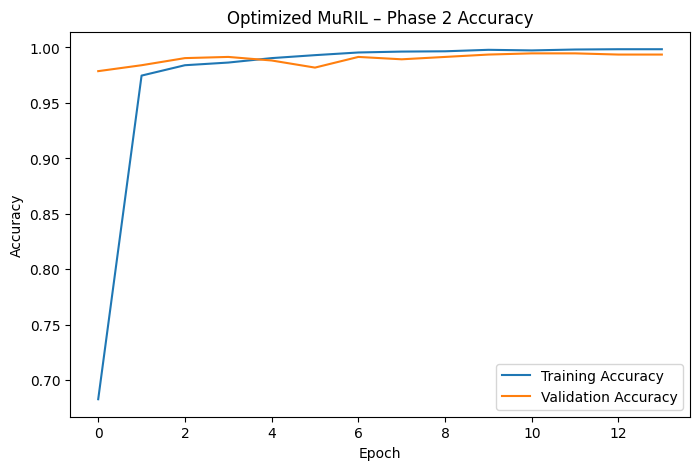

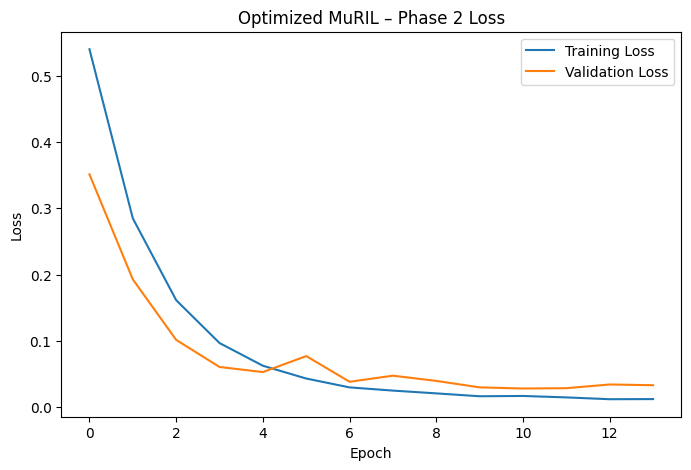

In [19]:
#16
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_ft.history["accuracy"], label="Training Accuracy")
plt.plot(history_ft.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Optimized MuRIL – Phase 2 Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_ft.history["loss"], label="Training Loss")
plt.plot(history_ft.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimized MuRIL – Phase 2 Loss")
plt.legend()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Predict on validation set
pred_probs = model.predict(
    [val_enc["input_ids"], val_enc["attention_mask"]]
)

# Convert probabilities → labels
pred_labels = (pred_probs > 0.5).astype(int).flatten()

# Metrics
acc = accuracy_score(val_labels, pred_labels)
prec = precision_score(val_labels, pred_labels)
rec = recall_score(val_labels, pred_labels)
f1 = f1_score(val_labels, pred_labels)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nDetailed Classification Report:\n")
print(classification_report(val_labels, pred_labels))


30/30 [==============================] - 10s 340ms/step
Accuracy  : 0.9915
Precision : 0.9933
Recall    : 0.9933
F1 Score  : 0.9933

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       343
           1       0.99      0.99      0.99       593

    accuracy                           0.99       936
   macro avg       0.99      0.99      0.99       936
weighted avg       0.99      0.99      0.99       936